### 라이브러리 임포트

In [1]:
# --------------------------------------------------
# [1] 라이브러리 임포트 및 시각화 설정 
# --------------------------------------------------
import duckdb
import polars as pl
import pandas as pd
import os
import platform
import matplotlib.pyplot as plt
import seaborn as sns

# Polars, Pandas 출력 옵션 설정
pl.Config.set_tbl_rows(10)
pd.set_option('display.max_columns', 100)

# 🚨 반드시 Seaborn 임포트 이후에 폰트 설정 실행
if platform.system() == 'Darwin':  # Mac 환경
    plt.rc('font', family='Apple SD Gothic Neo')
elif platform.system() == 'Windows':  # Windows 환경
    plt.rc('font', family='Malgun Gothic')
else:  # Linux (Google Colab 등) 환경
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드

In [2]:
# --------------------------------------------------
# [2] 파일 경로 설정 및 데이터 로드
# --------------------------------------------------
BASE_DIR = os.path.abspath('..')
PARQUET_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'sdot_master_2020_2026_cleaned.parquet')

print(f"데이터 경로: {PARQUET_PATH}")
print(f"파일 존재 여부: {os.path.exists(PARQUET_PATH)}\n")

# DuckDB에 Parquet 파일을 뷰(v_sdot)로 즉시 등록
# -> 메모리를 적게 차지하며, 이후 SQL 쿼리에서 'v_sdot' 테이블명으로 바로 호출 가능
duckdb.sql(f"CREATE OR REPLACE VIEW v_sdot AS SELECT * FROM read_parquet('{PARQUET_PATH}')")

# --------------------------------------------------
# [3] 데이터 정상 로드 확인
# --------------------------------------------------
query_check = """
    SELECT * 
    FROM v_sdot
    LIMIT 5
"""
print("📌 [데이터 미리보기]")
display(duckdb.sql(query_check).pl())

데이터 경로: /Users/gomdori/Documents/Git/sdot-analysis/data/processed/sdot_master_2020_2026_cleaned.parquet
파일 존재 여부: True

📌 [데이터 미리보기]


measure_time,sensor_id,temp_max,temp_avg,temp_min,humi_max,humi_avg,humi_min,wind_spd_max,wind_spd_avg,wind_spd_min,wind_dir_max,wind_dir_avg,wind_dir_min,illu_max,illu_avg,illu_min,uv_max,uv_avg,uv_min,noise_max,noise_avg,noise_min,vibe_x_max_g,vibe_x_avg_g,vibe_x_min_g,vibe_y_max_g,vibe_y_avg_g,vibe_y_min_g,vibe_z_max_g,vibe_z_avg_g,vibe_z_min_g,vibe_x_max_mms,vibe_x_avg_mms,vibe_x_min_mms,vibe_y_max_mms,vibe_y_avg_mms,…,flag_vibe_z_avg_g,flag_vibe_z_min_g,flag_vibe_x_max_mms,flag_vibe_x_avg_mms,flag_vibe_x_min_mms,flag_vibe_y_max_mms,flag_vibe_y_avg_mms,flag_vibe_y_min_mms,flag_vibe_z_max_mms,flag_vibe_z_avg_mms,flag_vibe_z_min_mms,flag_wbgt_max,flag_wbgt_avg,flag_wbgt_min,flag_no2_max,flag_no2_avg,flag_no2_min,flag_co_max,flag_co_avg,flag_co_min,flag_so2_max,flag_so2_avg,flag_so2_min,flag_nh3_max,flag_nh3_avg,flag_nh3_min,flag_h2s_max,flag_h2s_avg,flag_h2s_min,flag_o3_max,flag_o3_avg,flag_o3_min,flag_pm10,flag_pm25,latitude,longitude,gu_name
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str
"""2020-10-30 19:00""","""V02Q1940287""",null,15.9,null,null,39.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,44.0,null,0.13,0.06,null,0.12,0.01,null,1.09,1.02,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.531463,126.830075,"""양천구"""
"""2020-10-30 19:00""","""V02Q1940054""",null,16.1,null,null,36.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,45.0,null,0.08,0.02,null,0.15,0.08,null,1.28,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.490491,126.855378,"""구로구"""
"""2020-10-30 19:00""","""V02Q1940807""",null,18.6,null,null,26.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,49.0,null,0.14,0.07,null,0.16,0.1,null,1.12,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.573116,127.020059,"""종로구"""
"""2020-10-30 19:00""","""V02Q1940799""",null,16.2,null,null,34.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,46.0,null,0.07,0.02,null,0.12,0.02,null,1.11,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.637817,127.038271,"""도봉구"""
"""2020-10-30 20:00""","""V02Q1940328""",null,14.8,null,null,36.0,null,0.0,0.0,null,0.0,0.0,null,null,0.0,null,null,0.0,null,null,46.0,null,0.08,0.02,null,0.13,0.06,null,1.13,1.06,null,null,null,null,null,null,…,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,37.603348,127.029376,"""성북구"""


# 위치미상(메타데이터 누락 의심) 센서 ID 확인

In [13]:
import pandas as pd

# 1. DuckDB 뷰에서 위치미상 센서 ID 추출
query_missing_meta = """
    SELECT DISTINCT sensor_id
    FROM v_sdot
    WHERE gu_name = '위치미상'
"""
df_missing_meta = duckdb.sql(query_missing_meta).pl().to_pandas()
missing_sensors = df_missing_meta['sensor_id'].dropna().tolist()

# 2. 메타데이터 엑셀 파일 로드 (이전 노트북 환경의 경로 참고)
meta_filepath = '../metadata/서울시 도시데이터 센서(S-DoT) 환경정보 설치 위치정보.xlsx'
try:
    # 이미 로드된 loc_df가 있다면 활용하고, 없다면 새로 읽어옵니다.
    meta_df = loc_df.copy()
except NameError:
    meta_df = pd.read_excel(meta_filepath)
    meta_df = meta_df.rename(columns={'모델 시리얼(*)': '시리얼'})

# 3. 메타데이터의 시리얼 관련 모든 컬럼 값 추출하여 하나의 집합(Set)으로 만들기
all_meta_serials = set()
for col in ['시리얼', '변경 전 시리얼', '변경 전 시리얼(데이터 상 표기)']:
    if col in meta_df.columns:
        # 결측치를 제외하고 문자열로 변환하여 세트에 추가
        all_meta_serials.update(meta_df[col].dropna().astype(str).str.strip().tolist())

# 4. 교차 검증: 위치미상 센서들이 메타데이터 시리얼 집합에 포함되는지 확인
really_missing = []
found_in_meta = []

for sid in missing_sensors:
    if sid in all_meta_serials:
        found_in_meta.append(sid)
    else:
        really_missing.append(sid)
        
print(f"🔍 검증 대상 '위치미상' 센서 개수: {len(missing_sensors)}개")
print("-" * 50)

if found_in_meta:
    print(f"⚠️ 앗! 메타데이터 엑셀에 존재하는데 매핑 과정에서 누락된 센서가 {len(found_in_meta)}개 있습니다.")
    print(f"👉 누락된 센서 리스트: {found_in_meta}")
    print("매핑 로직이나 문자열 공백 등의 문제를 다시 점검해야 합니다.")
else:
    print(f"❌ (진짜로 메타데이터에 없는 센서: {len(really_missing)}개)")

🔍 검증 대상 '위치미상' 센서 개수: 0개
--------------------------------------------------
❌ (진짜로 메타데이터에 없는 센서: 0개)


In [15]:
query_missing_meta = """
    SELECT 
        sensor_id,
        MIN(measure_time) AS 최초_수집일,
        MAX(measure_time) AS 최종_수집일
    FROM v_sdot
    WHERE gu_name = '위치미상'
    GROUP BY sensor_id
    ORDER BY 최종_수집일 DESC
"""
df_missing_meta = duckdb.sql(query_missing_meta).pl().to_pandas()

print(f"🚨 메타데이터 파일에 없는 것으로 추정되는 센서: {len(df_missing_meta)}개")
display(df_missing_meta)

🚨 메타데이터 파일에 없는 것으로 추정되는 센서: 0개


,sensor_id,최초_수집일,최종_수집일


# [0] 기상 및 환경 지표 결측치 비율 분석

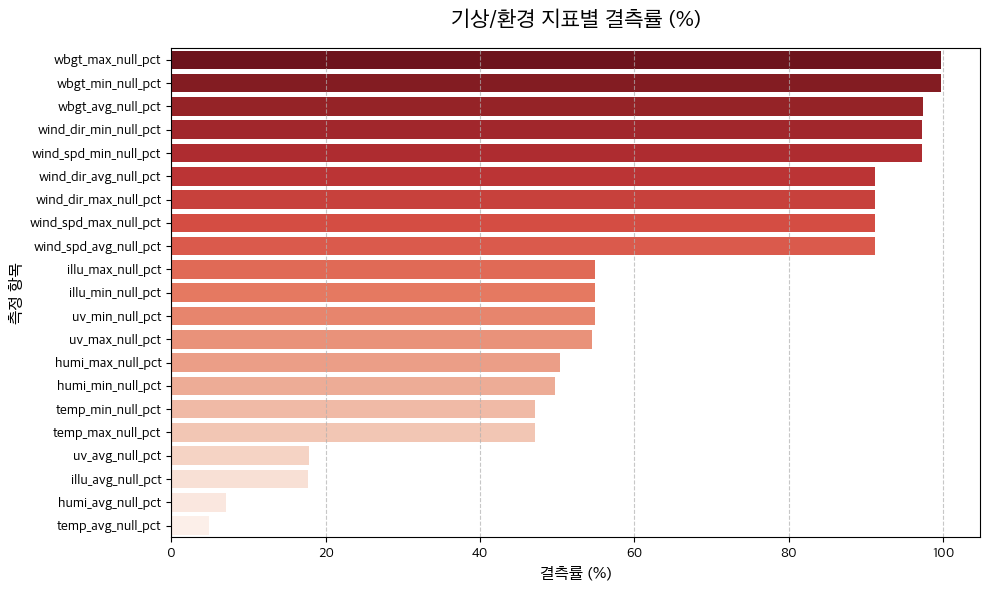

In [16]:
# 분석 대상 기상 컬럼
climate_cols = ['temp_min','temp_avg', 'temp_max',
                'humi_min','humi_avg', 'humi_max',
                'wind_spd_min','wind_spd_avg', 'wind_spd_max',
                'wind_dir_min','wind_dir_avg', 'wind_dir_max',
                'illu_min','illu_avg', 'illu_max',
                'uv_min','uv_avg', 'uv_max',
                'wbgt_min','wbgt_avg', 'wbgt_max']

# DuckDB를 이용해 각 컬럼별 NULL 카운트 및 총 행 수 계산
null_queries = []
for col in climate_cols:
    null_queries.append(f"SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS {col}_null_pct")

query_missing = f"SELECT {', '.join(null_queries)} FROM v_sdot"
df_missing = duckdb.sql(query_missing).pl().to_pandas().T
df_missing.columns = ['결측률(%)']
df_missing = df_missing.sort_values(by='결측률(%)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=df_missing['결측률(%)'], y=df_missing.index, hue=df_missing.index, palette='Reds_r', legend=False)

plt.title("기상/환경 지표별 결측률 (%)", fontsize=16, pad=15)
plt.xlabel("결측률 (%)", fontsize=12)
plt.ylabel("측정 항목", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# [4] 기상 지표 수집 간격(분) 분포 분석

In [22]:
# [4] 기상 지표 수집 간격(분) 분포 분석
climate_cols = ['temp_min','temp_avg', 'temp_max',
                'humi_min','humi_avg', 'humi_max',
                'wind_spd_min','wind_spd_avg', 'wind_spd_max',
                'wind_dir_min','wind_dir_avg', 'wind_dir_max',
                'illu_min','illu_avg', 'illu_max',
                'uv_min','uv_avg', 'uv_max',
                'wbgt_min','wbgt_avg', 'wbgt_max']

# 1. SELECT 절에서 모든 대상 컬럼을 명시적으로 DOUBLE형으로 캐스팅
casted_cols = [f"TRY_CAST({col} AS DOUBLE) AS {col}" for col in climate_cols]
climate_cols_cast_str = ", ".join(casted_cols)

# 2. UNPIVOT ON 절에는 컬럼 이름만 필요
climate_cols_str = ", ".join(climate_cols) 

# 🚨 수정됨: sensor_id, measure_time 이름 변경 및 TIMESTAMP 변환 로직 추가
query_interval = f"""
    WITH parsed_data AS (
        -- 1. 시간 문자열을 TIMESTAMP로 변환하고 센서 ID 맞추기 (사전 정제)
        SELECT 
            sensor_id,
            -- '_' 문자를 공백으로 바꿔준 뒤 실제 시간 데이터(TIMESTAMP)로 캐스팅
            TRY_CAST(REPLACE(measure_time, '_', ' ') AS TIMESTAMP) AS parsed_time,
            {climate_cols_cast_str}
        FROM v_sdot
    ),
    gap_calc AS (
        -- 2. 변환된 시간(parsed_time)을 기준으로 이전 시간(LAG)과의 차이(분 단위) 계산
        SELECT 
            sensor_id,
            parsed_time,
            DATE_DIFF('minute', 
                      LAG(parsed_time) OVER(PARTITION BY sensor_id ORDER BY parsed_time), 
                      parsed_time) AS time_gap_minutes,
            {climate_cols_str}
        FROM parsed_data
    ),
    unpivoted_gaps AS (
        -- 3. UNPIVOT 적용
        UNPIVOT gap_calc
        ON {climate_cols_str}
        INTO
            NAME measure_type
            VALUE measure_value
    )
    SELECT 
        measure_type AS 측정_항목,
        MEDIAN(time_gap_minutes) AS 중앙값_간격_분,
        ROUND(AVG(time_gap_minutes), 1) AS 평균_간격_분
    FROM unpivoted_gaps
    WHERE measure_value IS NOT NULL
      AND time_gap_minutes > 0  
    GROUP BY measure_type
    ORDER BY 중앙값_간격_분 ASC, 측정_항목 ASC
"""
df_interval = duckdb.sql(query_interval).pl().to_pandas()

print("📌 [기상 지표별 실제 측정 주기]")
display(df_interval)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📌 [기상 지표별 실제 측정 주기]


,측정_항목,중앙값_간격_분,평균_간격_분
0,humi_avg,60.0,76.7
1,humi_max,60.0,84.3
2,humi_min,60.0,84.1
3,illu_avg,60.0,76.9
4,illu_max,60.0,84.0
5,illu_min,60.0,84.0
6,temp_avg,60.0,76.3
7,temp_max,60.0,83.2
8,temp_min,60.0,83.2
9,uv_avg,60.0,76.8


# [5] 연도별 월별 결측률 시각화

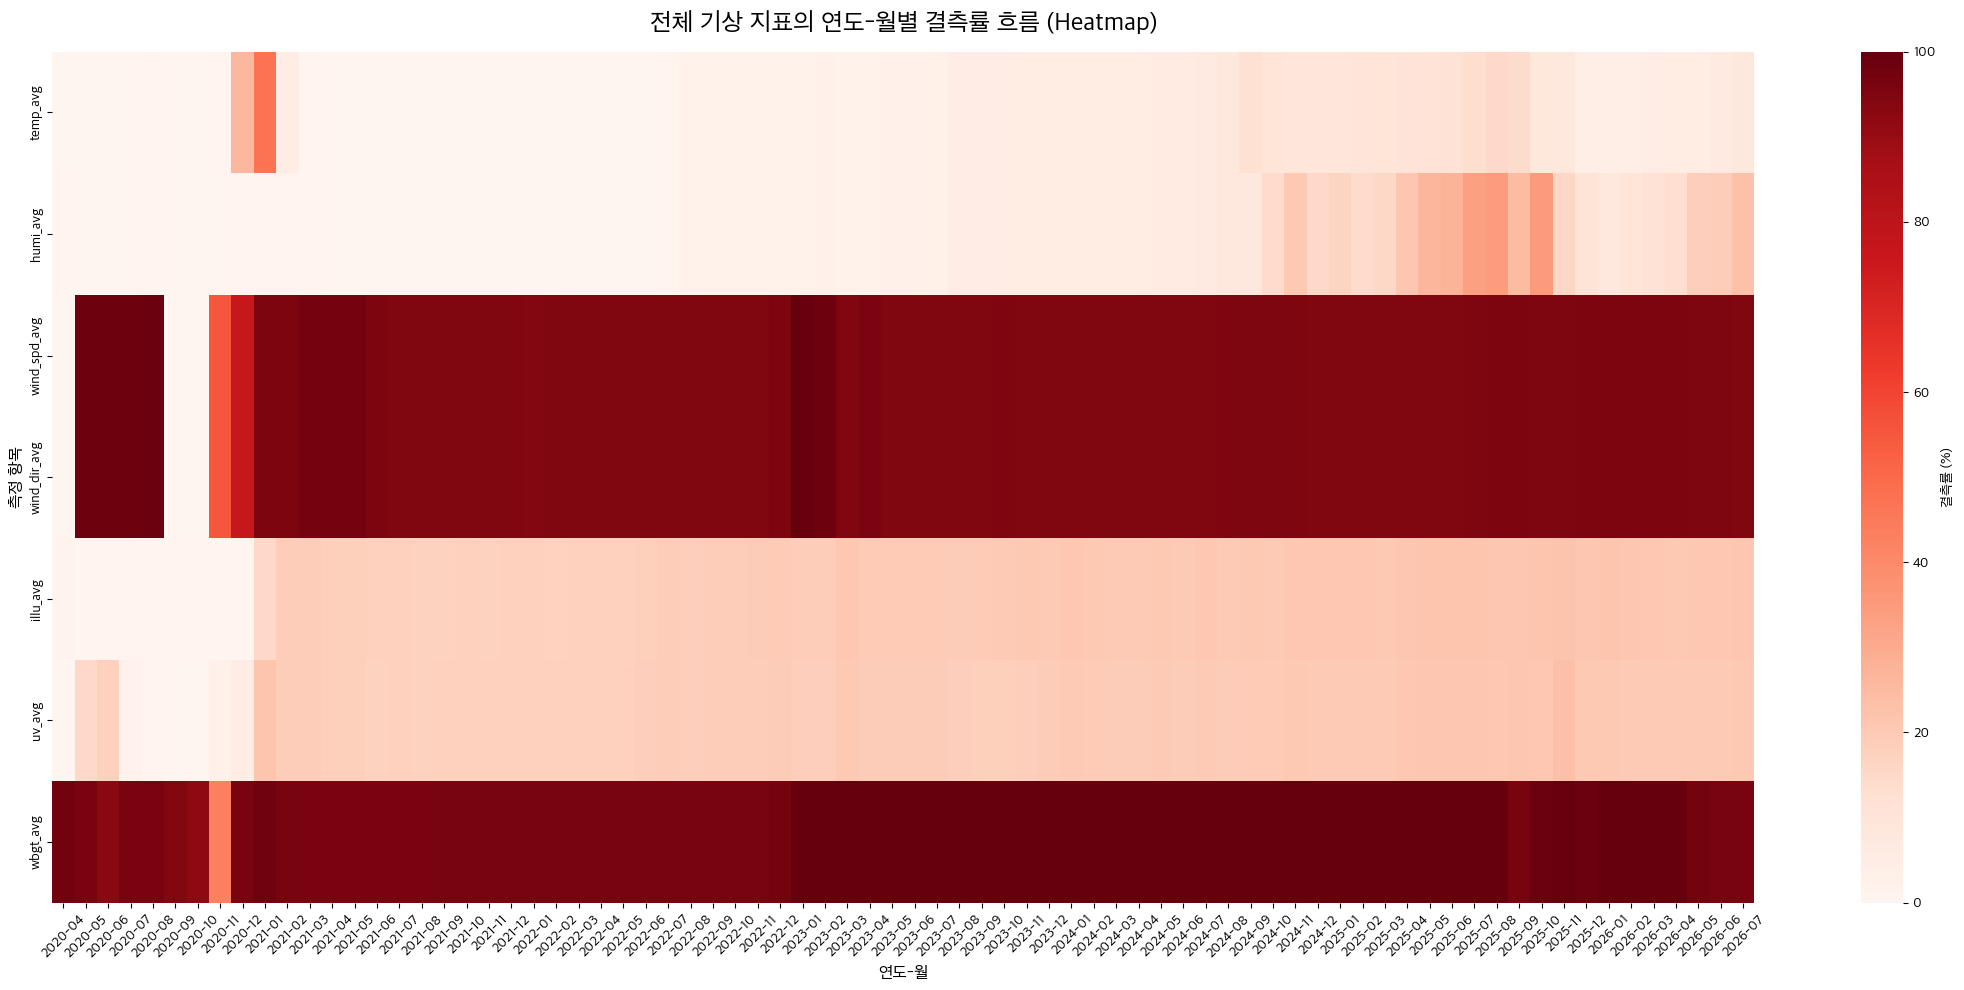

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

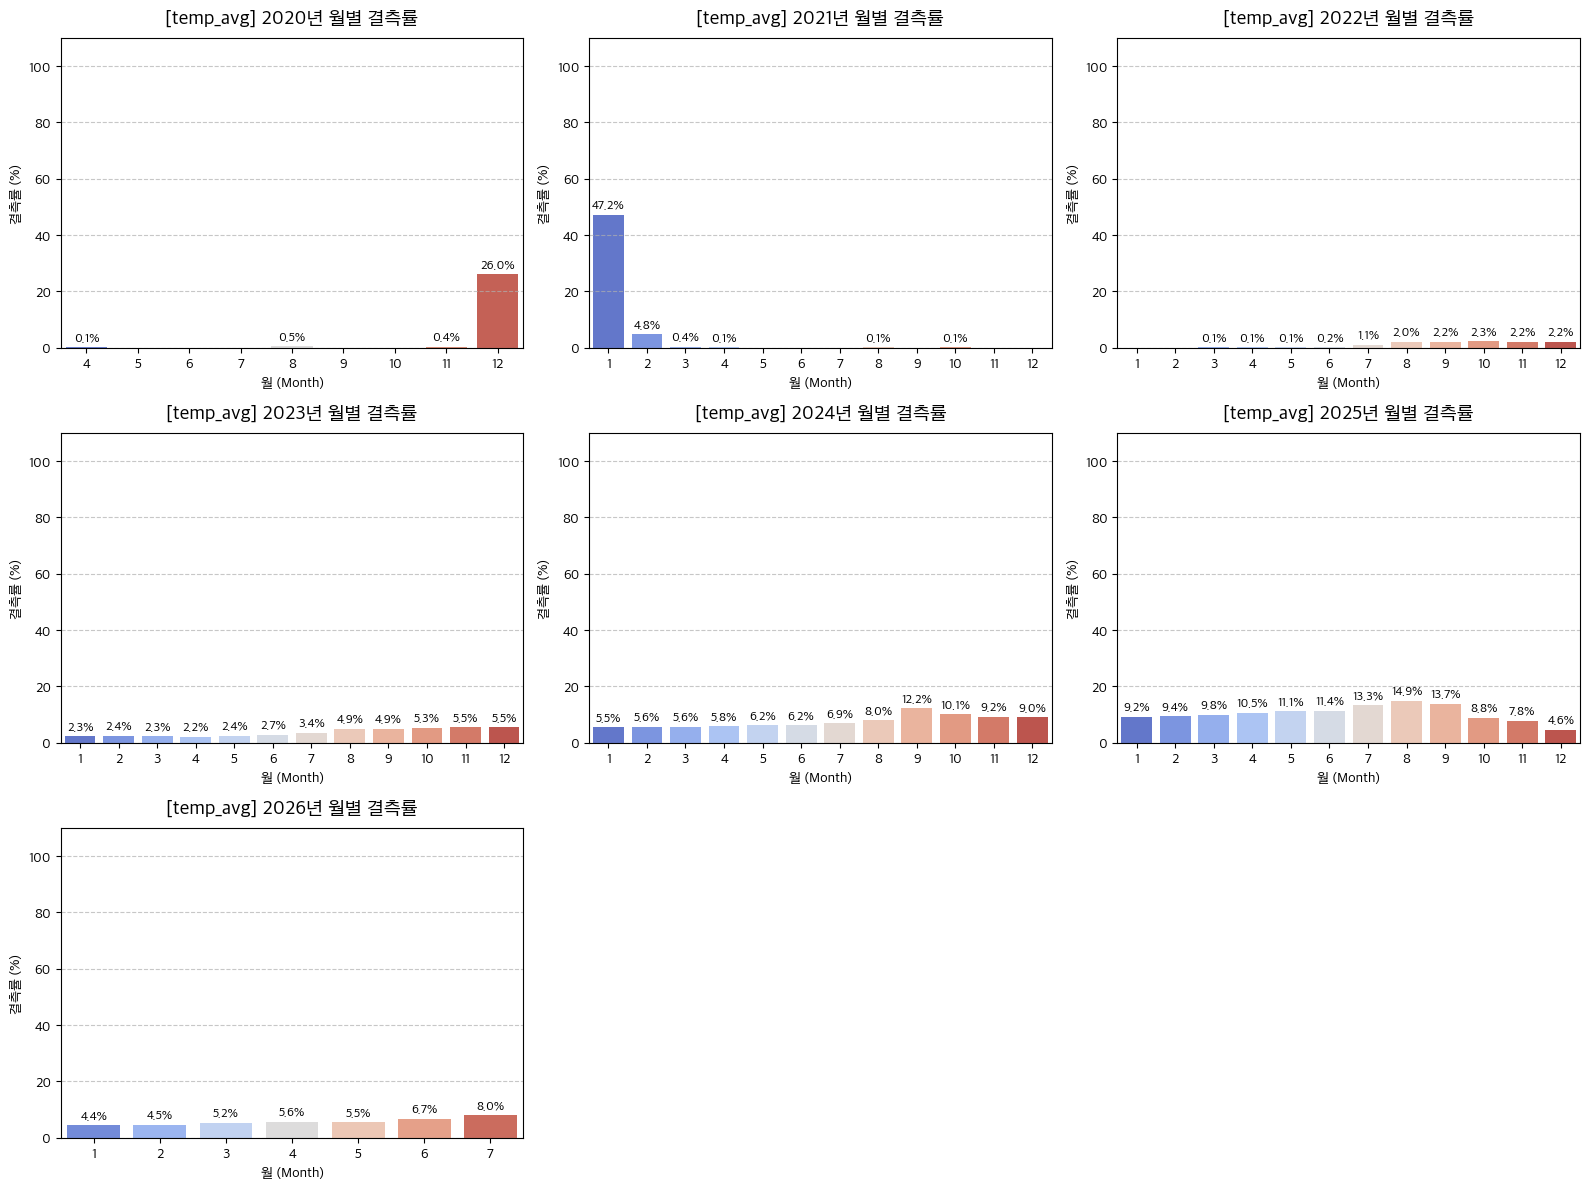

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

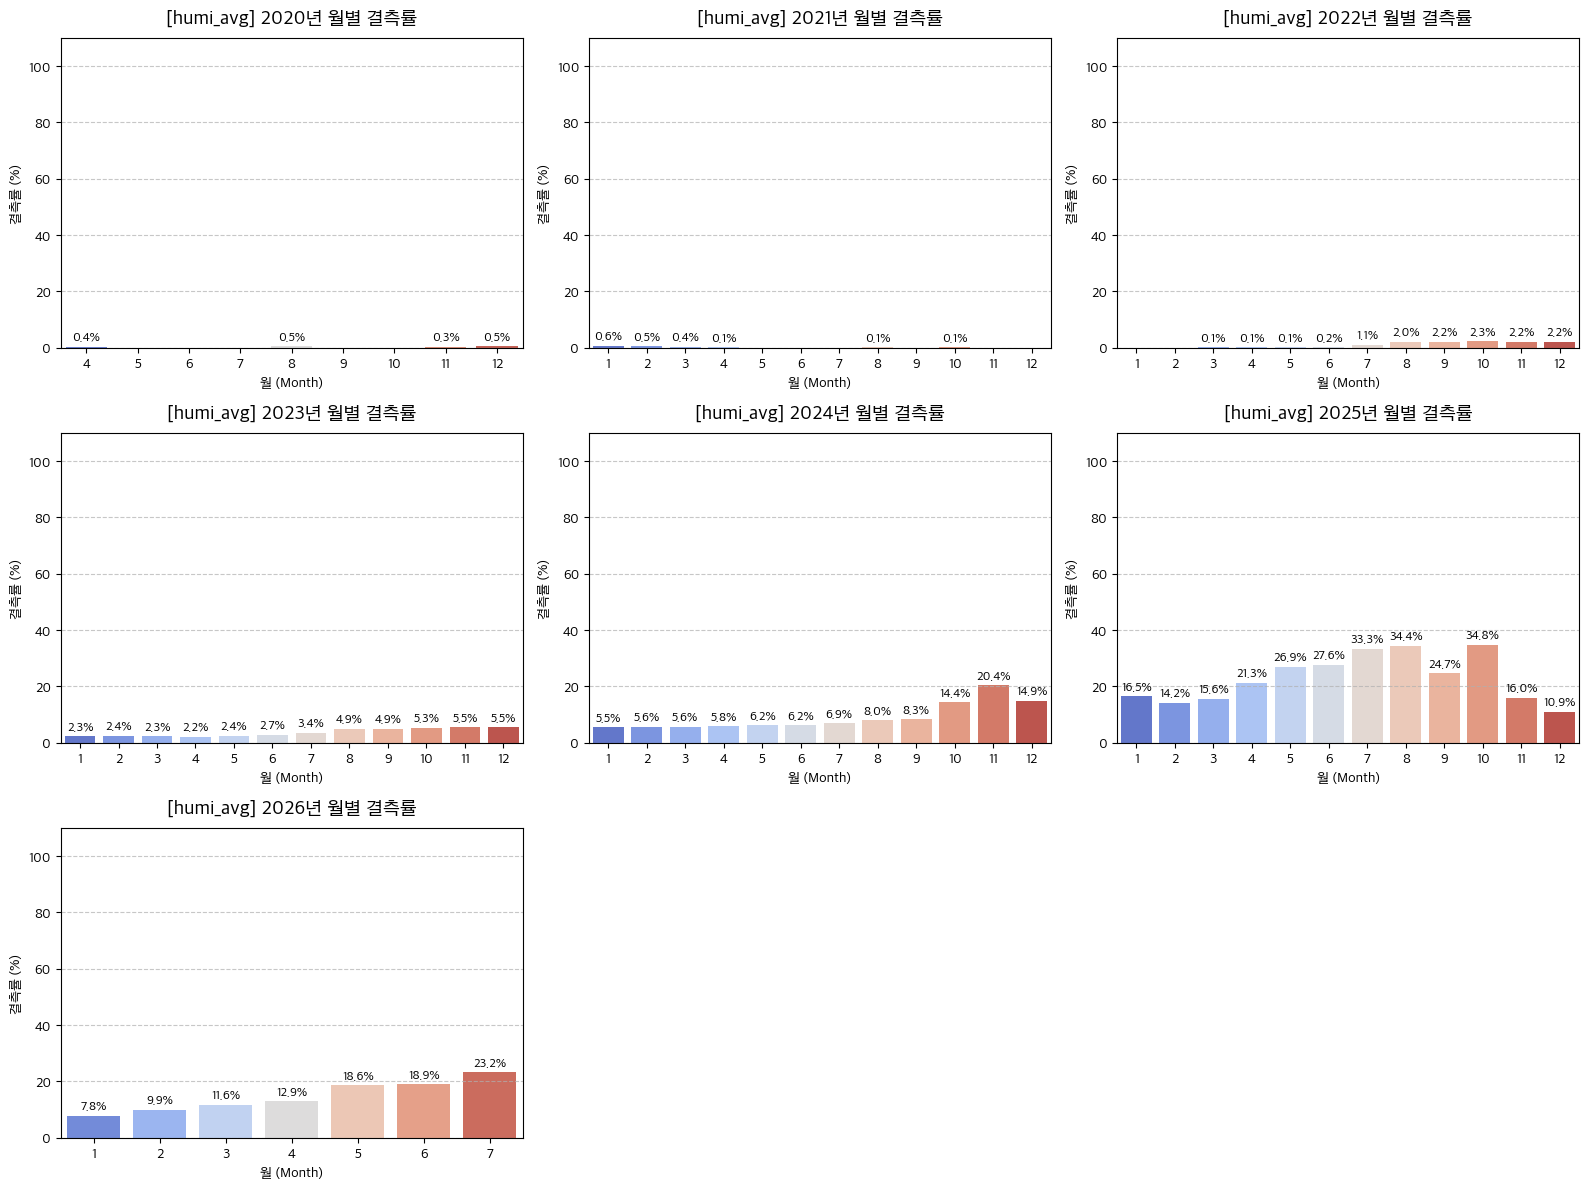

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

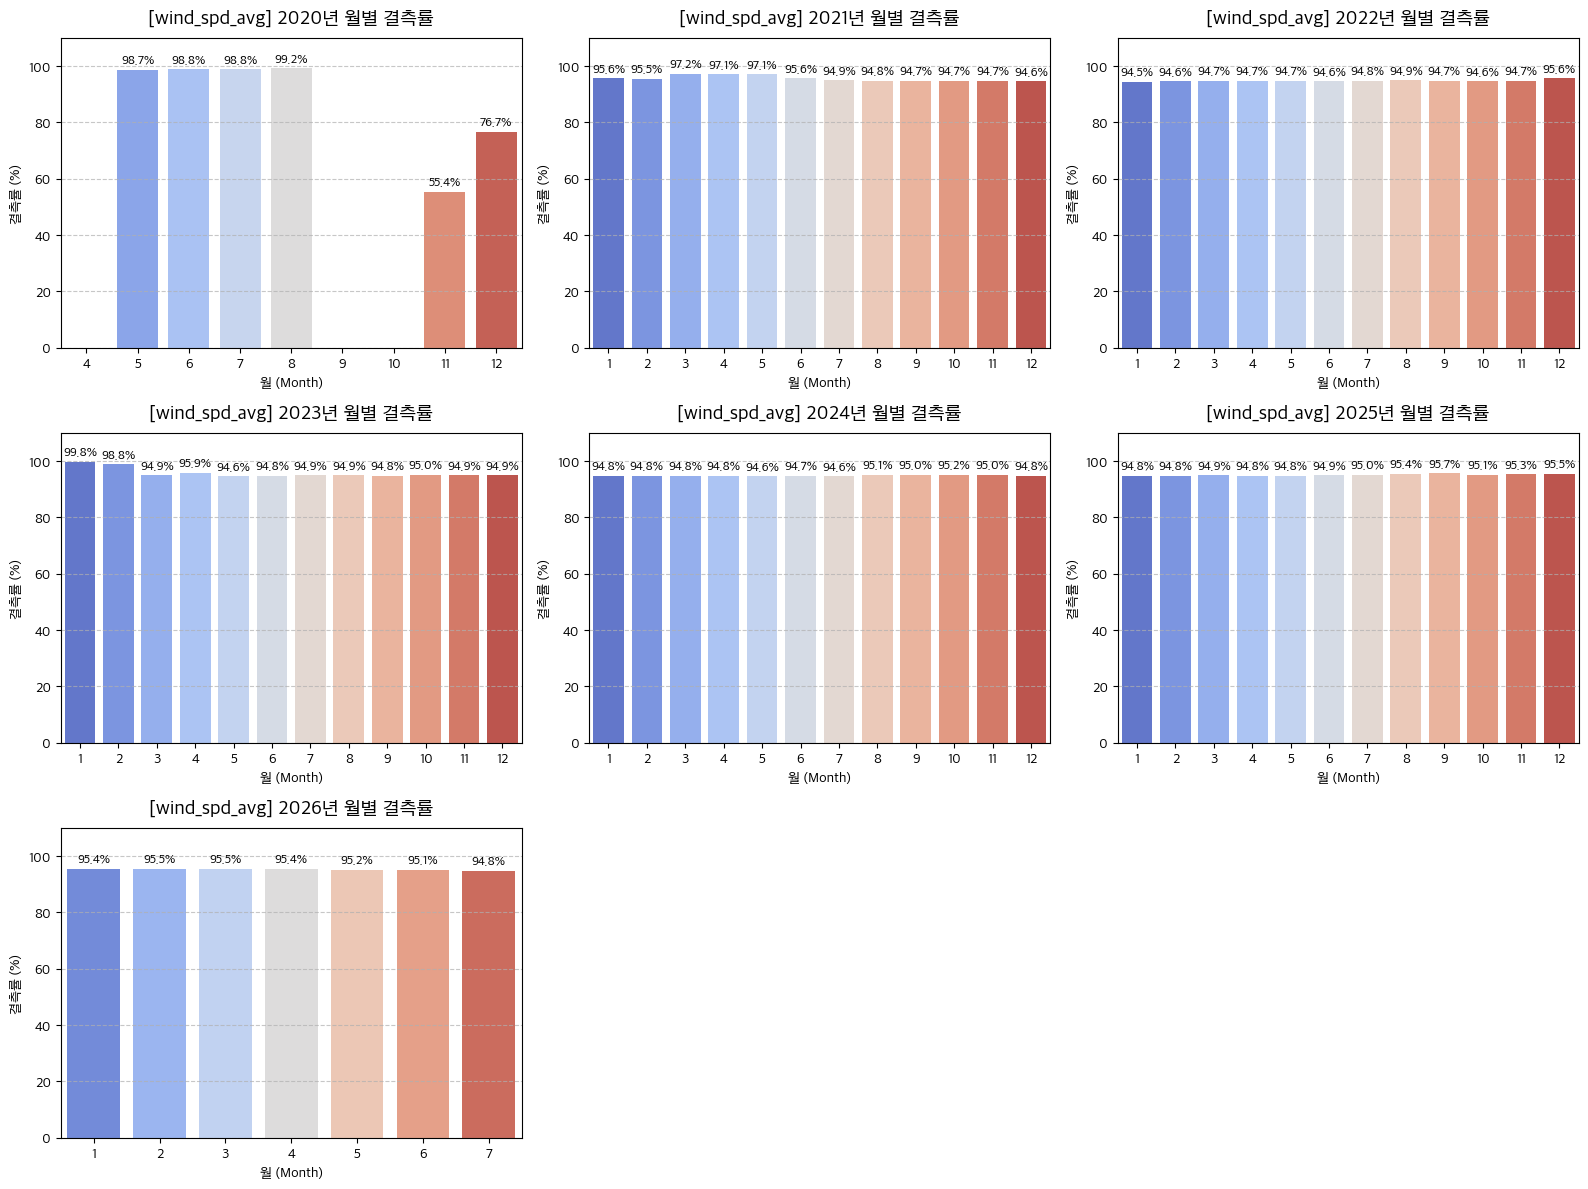

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

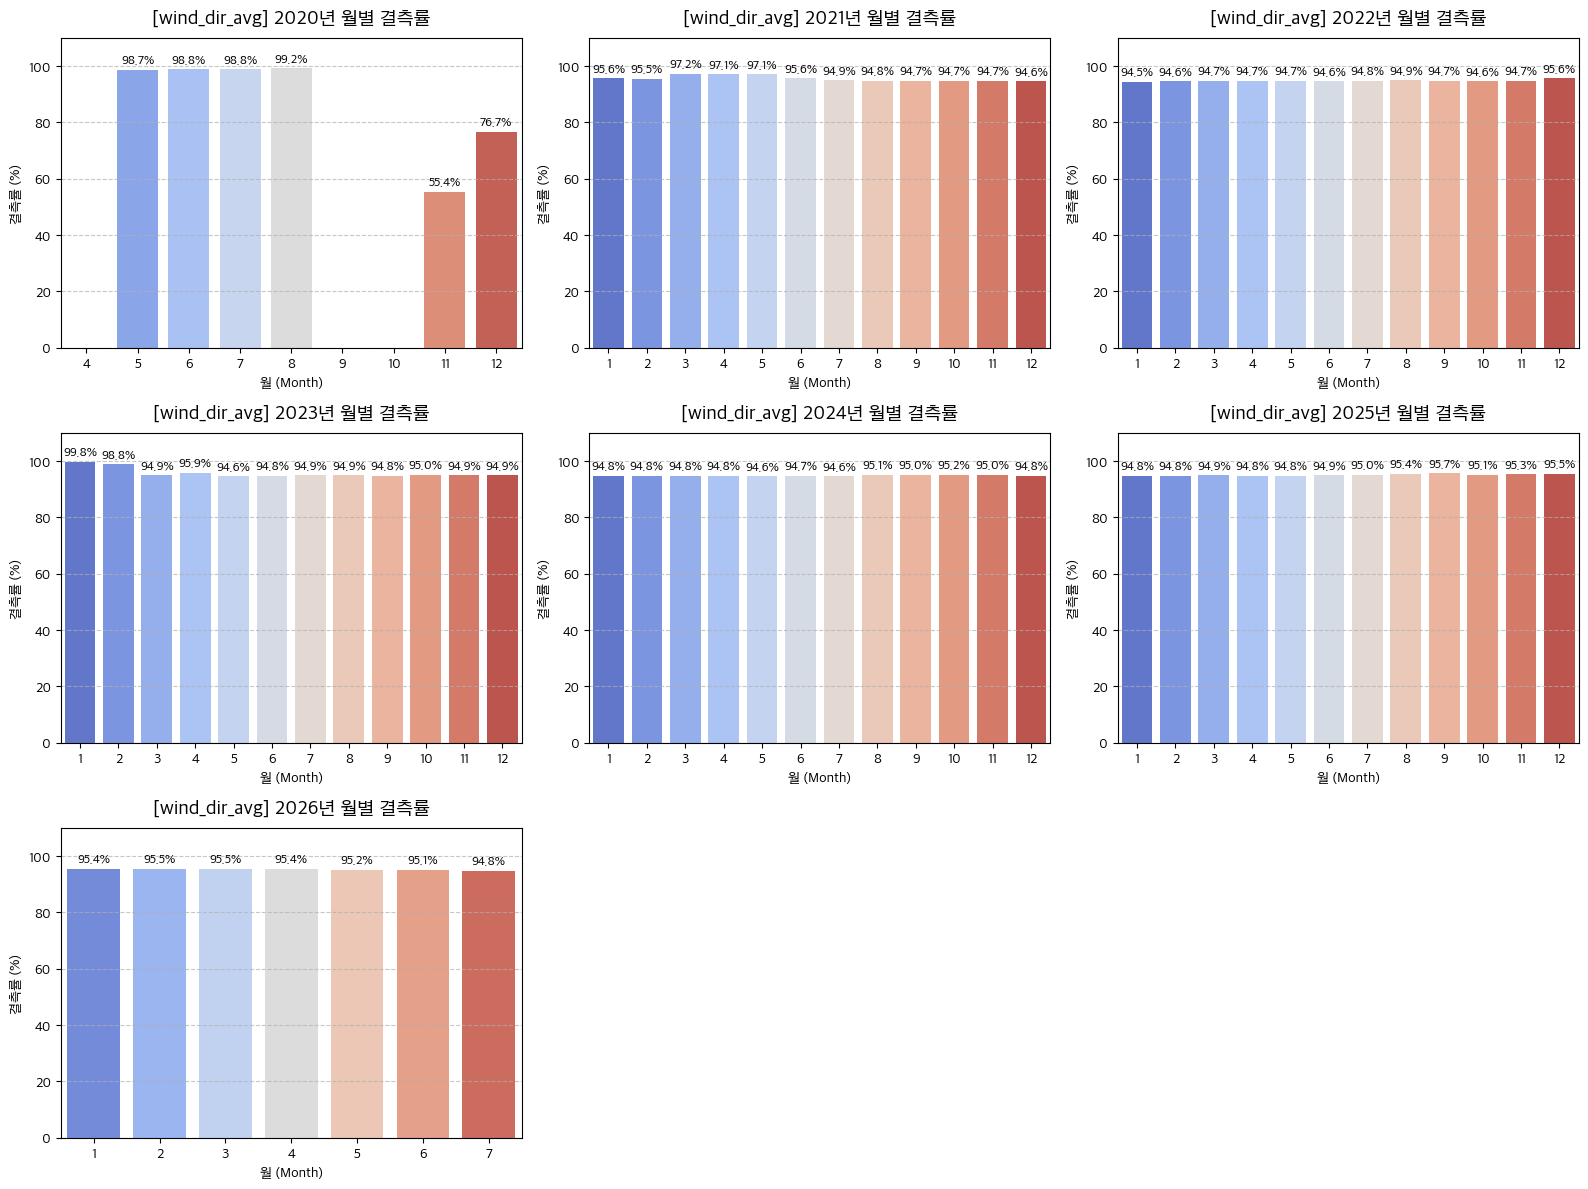

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

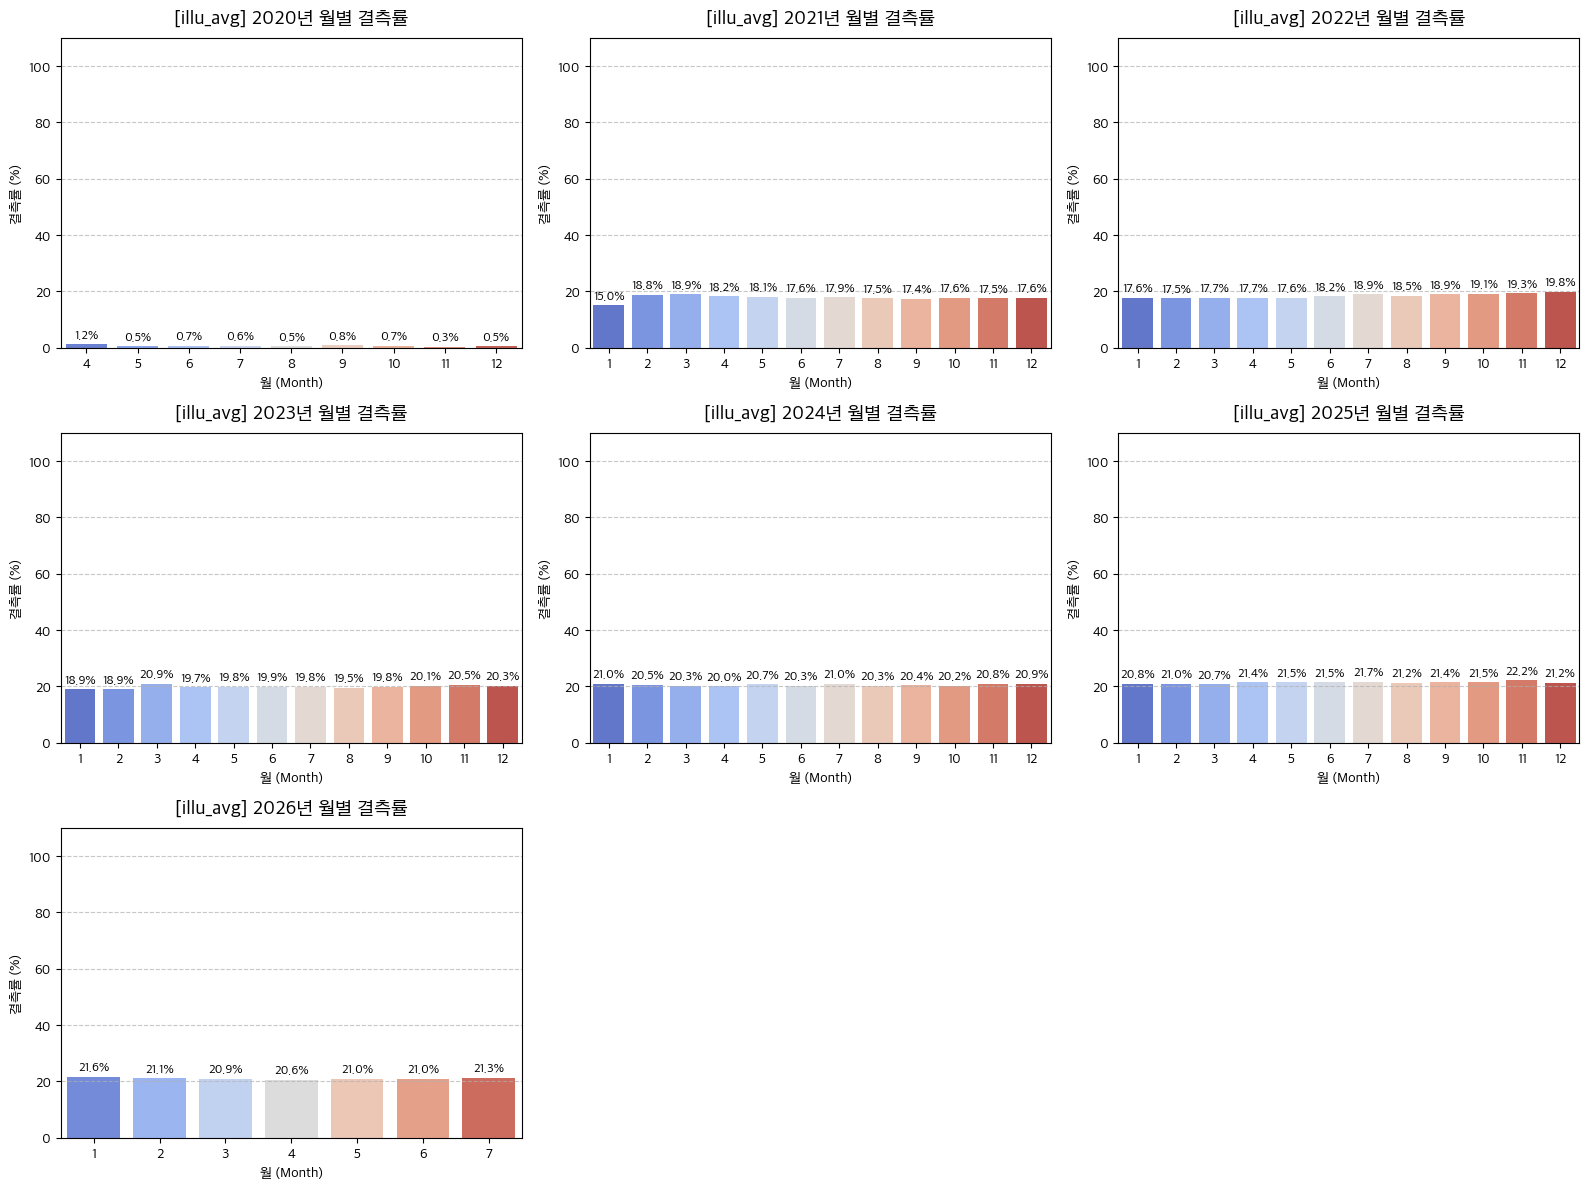

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

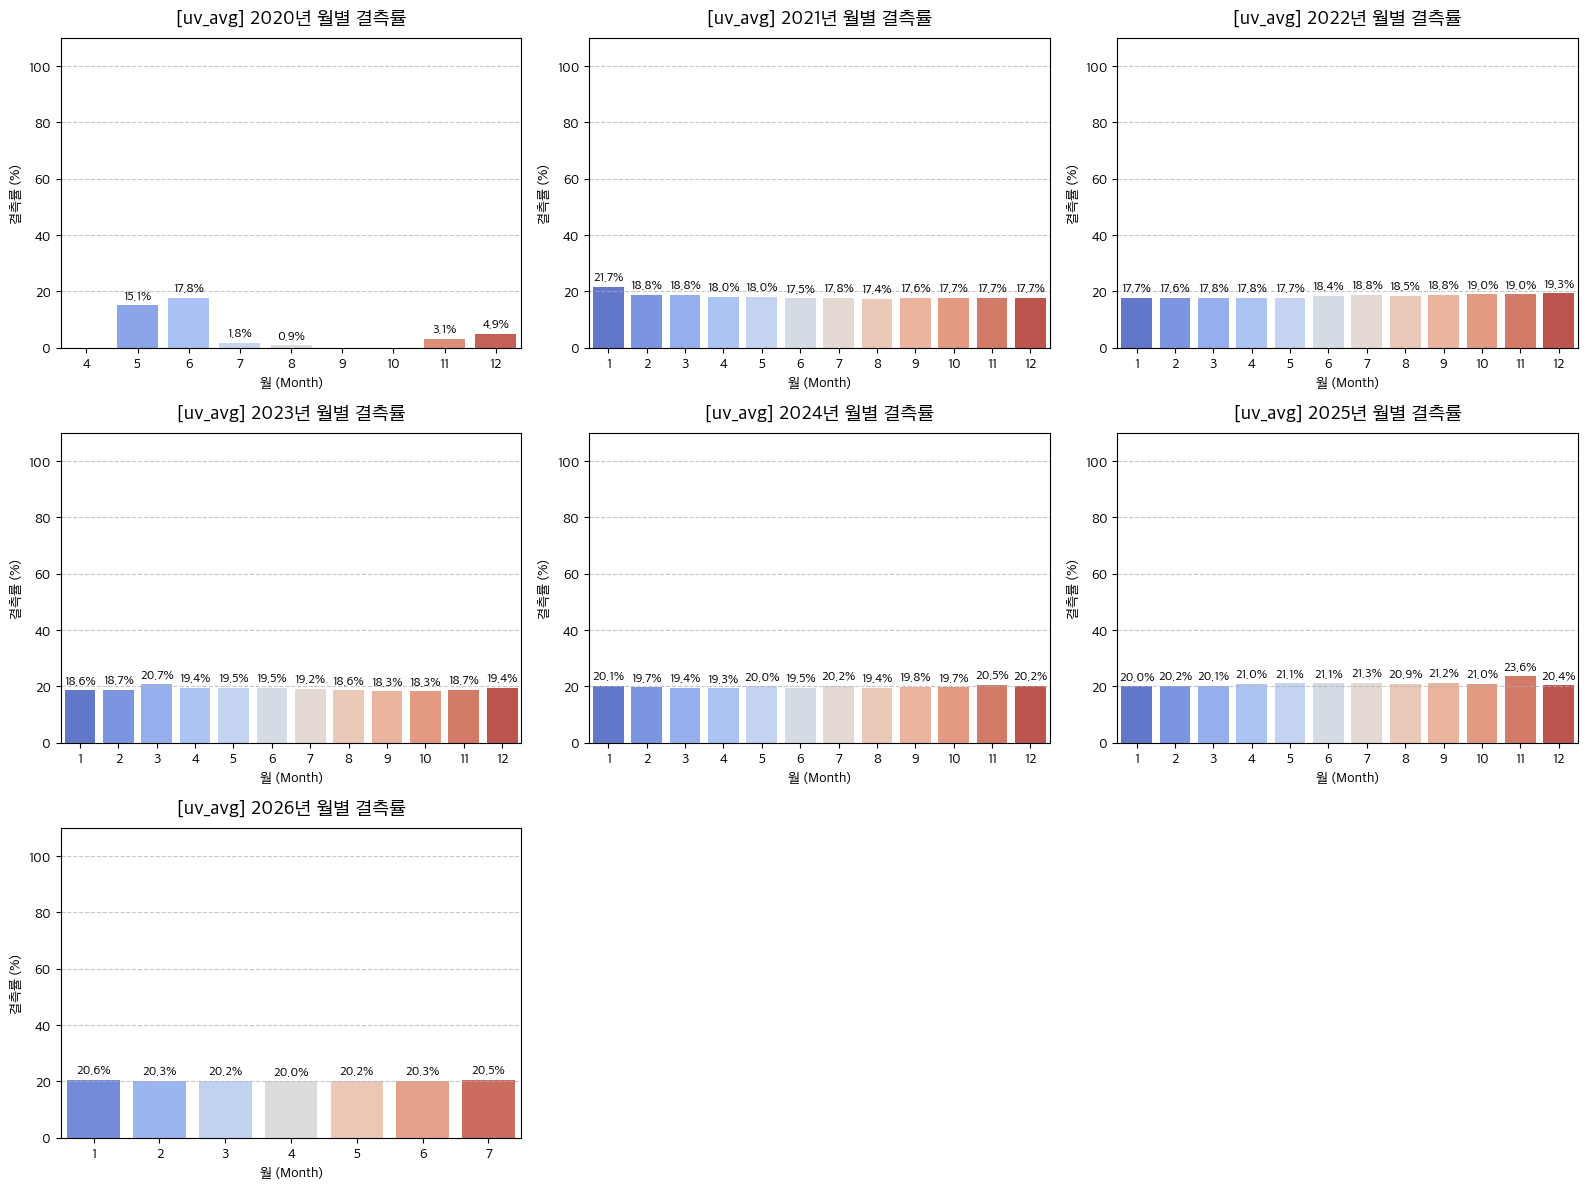

/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
/var/folders/c6/_5q2k4291yj3lw8b4k_0fc8m0000gn/T/ipykernel_15409/1928790093.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=year_data, x='month',

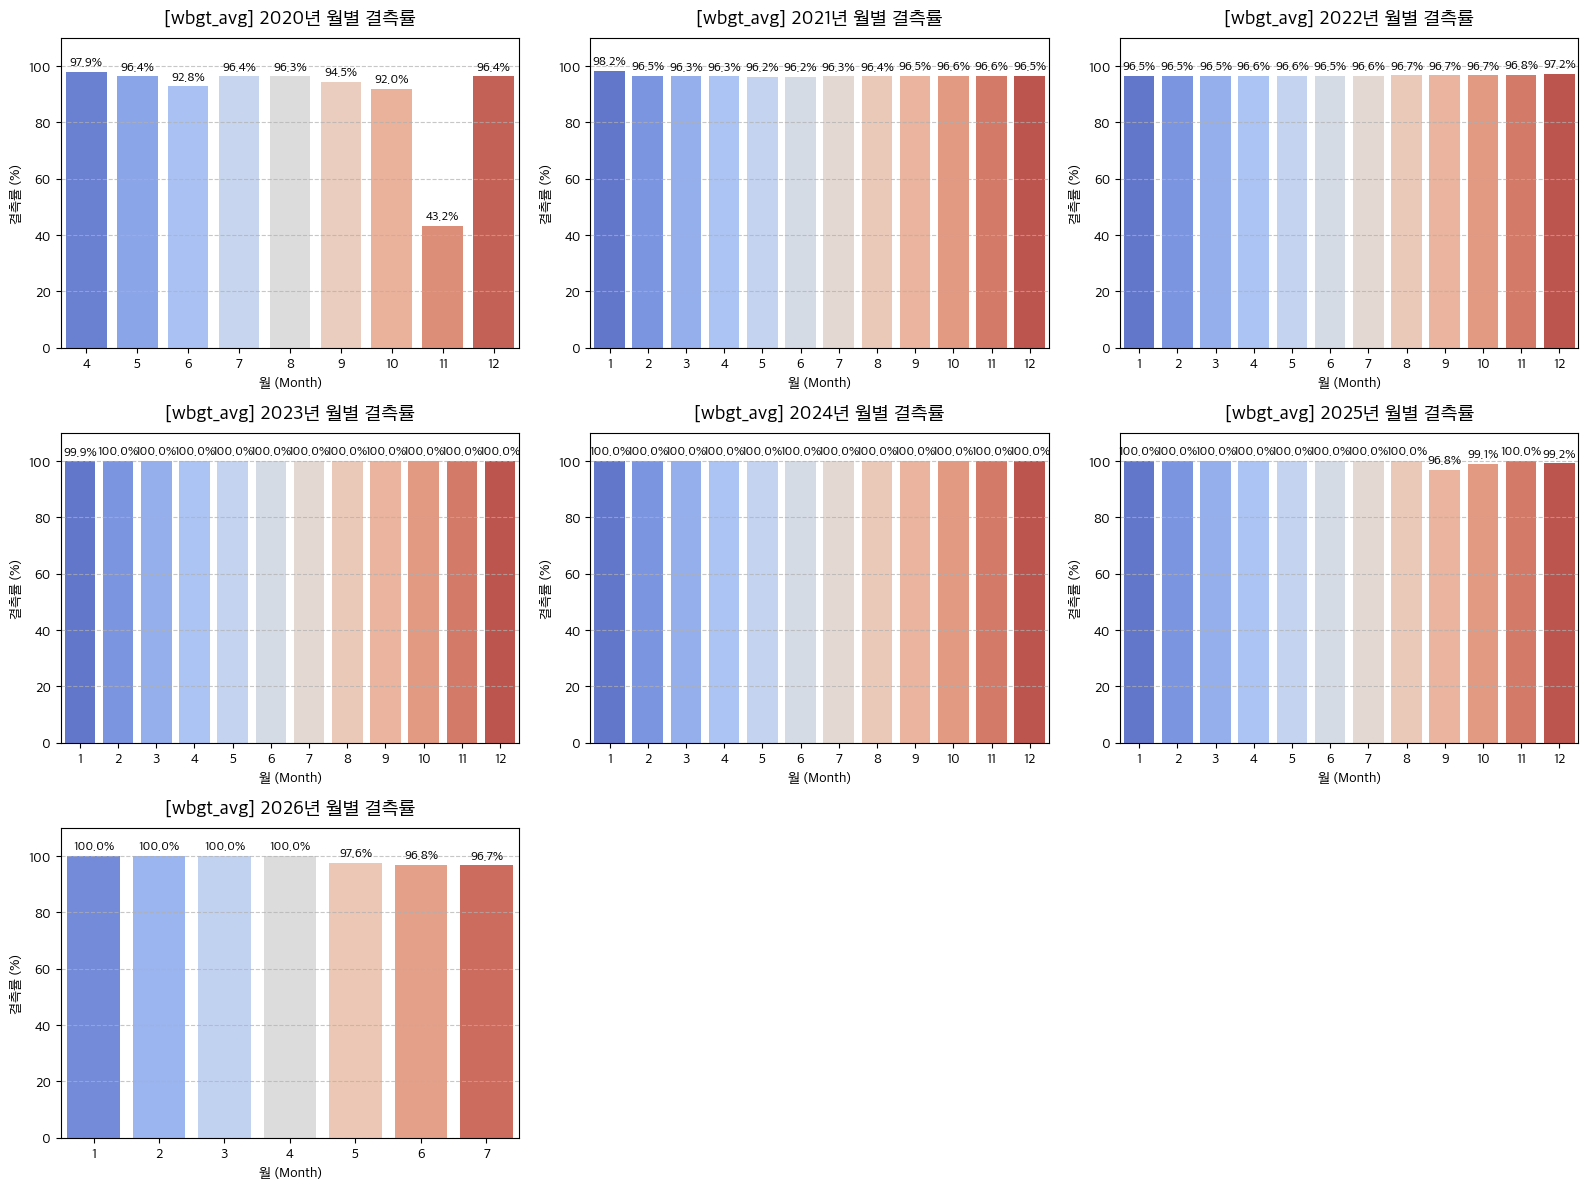

In [23]:
# --------------------------------------------------
# [1] 모든 기상 지표의 연도별/월별 결측률 통합 분석 및 시각화
# --------------------------------------------------
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

climate_cols = ['temp_avg','humi_avg', 'wind_spd_avg','wind_dir_avg', 'illu_avg', 'uv_avg', 'wbgt_avg']

# 1. 쿼리 생성: 모든 컬럼의 연-월별 결측률을 단일 쿼리로 계산
null_pct_sqls = [f"ROUND(SUM(CASE WHEN {col} IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS {col}" for col in climate_cols]
null_pct_sql_str = ",\n        ".join(null_pct_sqls)

# 🚨 EXTRACT 대신 SUBSTRING으로 문자열을 잘라서 정수(INTEGER)로 변환
query_all_seasonal = f"""
    SELECT 
        CAST(SUBSTRING(measure_time, 1, 4) AS INTEGER) AS year,
        CAST(SUBSTRING(measure_time, 6, 2) AS INTEGER) AS month,
        {null_pct_sql_str}
    FROM v_sdot
    GROUP BY year, month
    ORDER BY year, month
"""
df_all_seasonal = duckdb.sql(query_all_seasonal).df()

# --------------------------------------------------
# [시각화 1] 전체 지표 결측률 타임라인 히트맵 (거시적 관점)
# --------------------------------------------------
# 'YYYY-MM' 형식의 파생 컬럼 생성
df_all_seasonal['year_month'] = df_all_seasonal['year'].astype(int).astype(str) + '-' + df_all_seasonal['month'].astype(int).astype(str).str.zfill(2)
df_heatmap = df_all_seasonal.set_index('year_month')[climate_cols].T

plt.figure(figsize=(22, 10))
sns.heatmap(df_heatmap, cmap='Reds', annot=False, cbar_kws={'label': '결측률 (%)'})
plt.title("전체 기상 지표의 연도-월별 결측률 흐름 (Heatmap)", fontsize=18, pad=15)
plt.xlabel("연도-월", fontsize=12)
plt.ylabel("측정 항목", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# [시각화 2] 지표별 연도/월별 3열 Grid 바 차트 (미시적 관점)
# --------------------------------------------------
years = sorted(df_all_seasonal['year'].dropna().unique())
cols = 3
rows = math.ceil(len(years) / cols)

def plot_seasonal_nulls_for_item(item_name):
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(16, 4 * rows))
    axes = axes.flatten()
    
    for i, year in enumerate(years):
        ax = axes[i]
        year_data = df_all_seasonal[df_all_seasonal['year'] == year]
        
        sns.barplot(data=year_data, x='month', y=item_name, palette='coolwarm', ax=ax)
        
        ax.set_title(f"[{item_name}] {int(year)}년 월별 결측률", fontsize=14, pad=10)
        ax.set_xlabel("월 (Month)", fontsize=10)
        ax.set_ylabel("결측률 (%)", fontsize=10)
        ax.set_ylim(0, 110) # 텍스트 잘림 방지
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # 막대 위에 % 표시
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(f"{height}%", 
                            (p.get_x() + p.get_width() / 2., height), 
                            ha='center', va='bottom', fontsize=9, color='black', 
                            xytext=(0, 4), textcoords='offset points')
                            
    # 데이터가 없는 남은 subplot 숨기기
    for j in range(len(years), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# 21개 지표 모두에 대해 Grid 그래프 반복 출력
for col in climate_cols:
    plot_seasonal_nulls_for_item(col)

# [8] 지표별 전체 기간 결측 발생 분포

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

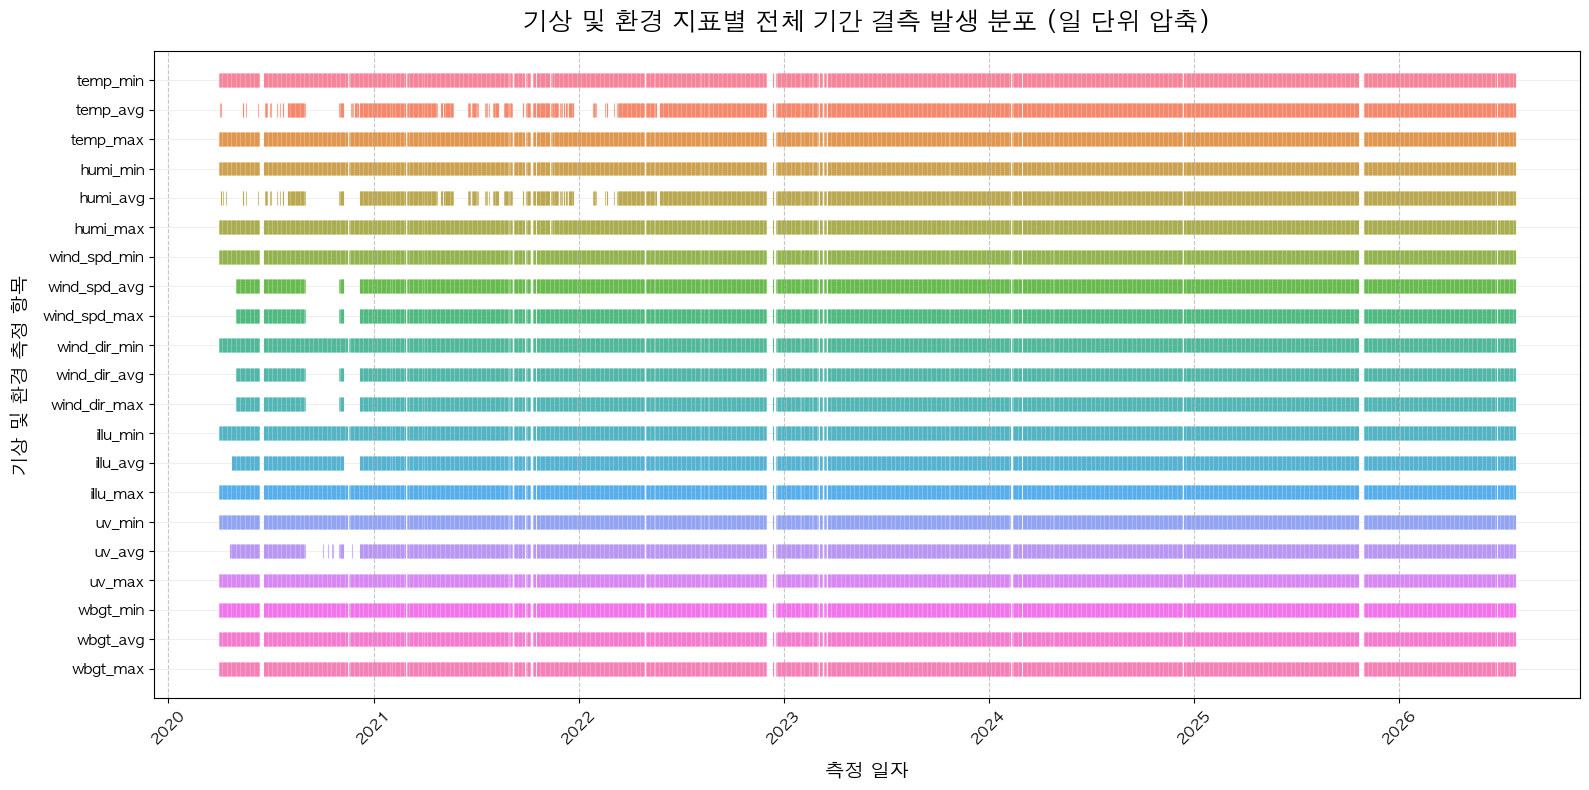

In [27]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
# plt.rc('font', family='Malgun Gothic') # Windows
plt.rc('font', family='AppleGothic') # Mac
plt.rcParams['axes.unicode_minus'] = False

climate_cols = ['temp_min','temp_avg', 'temp_max',
                'humi_min','humi_avg', 'humi_max',
                'wind_spd_min','wind_spd_avg', 'wind_spd_max',
                'wind_dir_min','wind_dir_avg', 'wind_dir_max',
                'illu_min','illu_avg', 'illu_max',
                'uv_min','uv_avg', 'uv_max',
                'wbgt_min','wbgt_avg', 'wbgt_max']

# --------------------------------------------------
# 1. 초경량화 데이터 추출: SPLIT_PART 활용 (들쭉날쭉 포맷 대응)
# --------------------------------------------------
queries = []
for col in climate_cols:
    q = f"""
        SELECT DISTINCT 
            -- 1. 언더바를 공백으로 바꿈 -> 2. 공백 기준으로 첫 번째(날짜) 조각만 쪼갬 -> 3. 마침표를 대시(-)로 바꿈 -> 4. DATE로 안전하게 캐스팅
            TRY_CAST(REPLACE(SPLIT_PART(REPLACE(measure_time, '_', ' '), ' ', 1), '.', '-') AS DATE) AS measure_date, 
            '{col}' AS indicator 
        FROM v_sdot 
        WHERE {col} IS NULL
    """
    queries.append(q)

query_lightweight = " UNION ALL ".join(queries)

# 쿼리 실행
df_missing_scatter = duckdb.sql(query_lightweight).df()
# 간혹 TRY_CAST 실패로 NaT가 된 쓰레기값 제거
df_missing_scatter = df_missing_scatter.dropna(subset=['measure_date'])
df_missing_scatter['measure_date'] = pd.to_datetime(df_missing_scatter['measure_date'])

# --------------------------------------------------
# 2. 산점도(Scatter Plot) 시각화
# --------------------------------------------------
plt.figure(figsize=(16, 8))

if df_missing_scatter.empty:
    print("🚨 결측 데이터가 없습니다.")
else:
    # y축 정렬
    order_list = list(reversed(climate_cols))
    
    sns.scatterplot(
        data=df_missing_scatter, 
        x='measure_date', 
        y='indicator', 
        hue='indicator',   
        marker='|',        
        s=100,             
        alpha=0.6,         
        legend=False       
    )

    plt.title('기상 및 환경 지표별 전체 기간 결측 발생 분포 (일 단위 압축)', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('측정 일자', fontsize=14, labelpad=10)
    plt.ylabel('기상 및 환경 측정 항목', fontsize=14, labelpad=10)

    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.grid(axis='y', linestyle='-', alpha=0.2)

    plt.yticks(fontsize=11)
    plt.xticks(fontsize=11, rotation=45)

    plt.tight_layout()
    plt.show()